In [173]:
from typing import TypedDict,List,Annotated,Literal, Optional
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage,HumanMessage
import operator
from __future__ import annotations
from dotenv import load_dotenv
from langchain_tavily import TavilySearch

In [174]:
load_dotenv()
llm=ChatGroq(
    model="openai/gpt-oss-120b",
)
tavily=TavilySearch()

worker_llm = ChatGroq(
    model="llama-3.1-8b-instant"
)


In [175]:
class Task(BaseModel):
    id: int

    title: str = Field(
        ...,
        description="Section title"
    )

    section_type: str = Field(
        ...,
        description="Introduction, Concept, Tutorial, Comparison, Use Case, Best Practices, Future Trends, etc."
    )

    target_words: int = Field(
        ...,
        description="Approximate word count for this section"
    )

    brief: str = Field(
        ...,
        description="Detailed description of what should be covered"
    )

    bullets: List[str] = Field(
        ...,
        description="Specific points that must be covered"
    )


class Plan(BaseModel):
    blog_title: str

    audience: str = Field(
        ...,
        description="Target audience of the blog"
    )

    tone: str = Field(
        ...,
        description="Writing tone"
    )

    goal: str = Field(
        ...,
        description="Main objective of the blog"
    )

    total_target_words: int = Field(
        ...,
        description="Approximate total word count"
    )

    tasks: List[Task]
  
  
class RouterDecision(BaseModel):

    needs_research: bool

    mode: Literal[
        "closed_book",
        "hybrid",
        "open_book"
    ]

    queries: List[str] = Field(
        default_factory=list,
        description="Search queries for research node"
    )
    
class EvidenceItem(BaseModel):

    title: str

    url: str

    published_at: Optional[str] = None

    snippet: Optional[str] = None

    source_type: Optional[str] = None
    
    
class EvidencePack(BaseModel):

    evidence: List[EvidenceItem]
    
class State(TypedDict):

    topic: str

    mode: str

    needs_research: bool

    queries: List[str]

    evidence_pack: EvidencePack

    plan: Plan

    sections: Annotated[
        List[str],
        operator.add
    ]

    final: str

In [176]:
ROUTER_SYSTEM="""You are an expert content planning router.

Your responsibility is to decide whether external research is required before generating a blog plan.

Available Modes
---------------

1. closed_book
   - needs_research = false
   - Use only internal knowledge.
   - Suitable for timeless educational topics.
   - Examples:
     - Binary Search
     - FastAPI Tutorial
     - OOP Concepts
     - LangGraph Basics
     - System Design Fundamentals

2. hybrid
   - needs_research = true
   - Use both internal knowledge and external research.
   - Suitable when recent examples, statistics, trends, or industry developments would improve the article.

3. open_book
   - needs_research = true
   - Research is mandatory.
   - Suitable for:
     - Recent events
     - Current technologies
     - AI model comparisons
     - Industry reports
     - Product launches
     - Market analysis
     - Benchmark comparisons
     - News-driven topics

Routing Rules
-------------

Choose closed_book when:
- The topic is educational and timeless.
- Core knowledge is sufficient.
- No recent information is required.

Choose hybrid when:
- The topic benefits from recent examples.
- Current industry practices improve article quality.
- Some research would be valuable but not essential.

Choose open_book when:
- The topic depends on recent information.
- Accuracy requires current facts.
- The user asks for:
  - latest
  - recent
  - this week
  - last week
  - this month
  - current
  - today
  - trends
  - benchmarks
  - rankings
  - news
  - 2025
  - 2026
  - future outlook

Research Query Generation
-------------------------

If needs_research = true:

Generate between 3 and 10 high-signal search queries.

Requirements:

- Queries must be highly specific.
- Avoid generic searches.
- Focus on information useful for writing the article.
- Include time references when relevant.
- Include industry terminology.
- Cover multiple perspectives if appropriate.
- Prioritize authoritative sources."""


def router_node(state:State)->dict:
  topic=state["topic"]
  decisor=llm.with_structured_output(RouterDecision)
  decision=decisor.invoke(
    [
      SystemMessage(content=ROUTER_SYSTEM),
      HumanMessage(content=f"Topic:{topic}")
    ]
  )
  
  return {
    "needs_research":decision.needs_research,
    "mode":decision.mode,
    "queries":decision.queries,
  }
  
  
def route_next(state:State)->str:
  return "research" if state["needs_research"] else "orchestrator"
  

In [177]:

def _tavily_search(
    query: str,
    max_results: int = 5
) -> List[dict]:

    response = tavily.invoke(
        {
            "query": query
        }
    )

    print(response)

    normalized = []

    for item in response.get("results", []):

        normalized.append(
            {
                "title": item.get("title", ""),
                "url": item.get("url", ""),
                "snippet": item.get("content", ""),
                "published_at": item.get("published_date"),
                "source": item.get("source")
            }
        )

    return normalized

RESEARCH_SYSTEM = """
You are a research synthesizer for technical writing.

Given raw web search results, produce a clean, deduplicated EvidencePack.

Rules:

- Only include items with non-empty URLs.
- Prefer authoritative and relevant sources.
- Keep snippets concise (1-3 sentences).
- Remove duplicate URLs.
- If a publication date exists, preserve it in YYYY-MM-DD format.
- Ignore low-quality, spammy, or irrelevant sources.
- Focus on evidence useful for writing the article.

Return only the structured output matching the EvidencePack schema.
"""
  
def research_node(state: State) -> dict:

    queries = state["queries"]

    max_results = 6

    raw_results: List[dict] = []

    for query in queries:
        raw_results.extend(
            _tavily_search(
                query=query,
                max_results=max_results
            )
        )

    if not raw_results:
        return {
            "evidence_pack": EvidencePack(
                evidence=[]
            )
        }

    extractor = llm.with_structured_output(
        EvidencePack
    )

    pack = extractor.invoke(
        [
            SystemMessage(
                content=RESEARCH_SYSTEM
            ),
            HumanMessage(
                content=f"""
Raw Search Results:

{raw_results}

Convert these results into a clean EvidencePack.
"""
            )
        ]
    )

    dedup = {}

    for item in pack.evidence:

        if not item.url:
            continue

        dedup[item.url] = item

    final_pack = EvidencePack(
        evidence=list(dedup.values())
    )

    print(
        f"Collected {len(final_pack.evidence)} evidence items"
    )

    return {
        "evidence_pack": final_pack
    }

In [178]:
def orchestrator(state: State) -> dict:

    topic = state["topic"]

    evidence_pack = state.get("evidence_pack")

    evidence_text = ""

    if evidence_pack and evidence_pack.evidence:

        evidence_chunks = []

        for e in evidence_pack.evidence[:15]:

            evidence_chunks.append(
                f"""
Title: {e.title}
URL: {e.url}
Published: {e.published_at}
Snippet: {e.snippet}
"""
            )

        evidence_text = "\n\n".join(evidence_chunks)

    structured_llm = llm.with_structured_output(Plan)

    plan = structured_llm.invoke(
        [
            SystemMessage(
                content="""
You are an expert content strategist, editor, and technical writer.

Your task is to create a complete blog plan.

Generate:

- blog_title
- audience
- tone
- goal
- total_target_words
- tasks

For every task generate:

- id
- title
- section_type
- target_words
- brief
- bullets

Requirements:

- Create 5-8 sections.
- Flow from beginner concepts to advanced topics.
- Avoid overlap.
- Cover practical applications.
- Include implementation details where useful.
- Create publication-quality structure.
- Avoid generic sections such as Conclusion or Summary.

If research evidence is provided:
- Use it for recent facts and trends.
- Use it to improve section planning.
- Do not blindly copy snippets.
- Prefer authoritative sources.

Return only the structured output.
"""
            ),
            HumanMessage(
                content=f"""
TOPIC:
{topic}

RESEARCH EVIDENCE:
{evidence_text}

Notes:
- Research evidence may be empty.
- Use evidence only when relevant.
- Use evidence for recent developments, statistics, trends, benchmarks, or industry insights.

Create a complete blog plan.
"""
            )
        ]
    )

    print("\n===== PLAN =====")
    print(plan.model_dump())
    print("================\n")

    return {
        "plan": plan
    }

In [179]:
def fanout(state: State):

    topic = state["topic"]

    plan = state["plan"]

    evidence_pack = state.get("evidence_pack")

    return [
        Send(
            "worker",
            {
                "task": task,
                "topic": topic,
                "plan": plan,
                "evidence_pack": evidence_pack,
                "mode": state["mode"],
                "needs_research": state["needs_research"],
            }
        )
        for task in plan.tasks
    ]

In [180]:
def worker(payload: dict) -> dict:

    task = payload["task"]

    topic = payload["topic"]

    plan = payload["plan"]

    evidence_pack = payload.get(
        "evidence_pack"
    )

    mode = payload.get(
        "mode",
        "closed_book"
    )

    needs_research = payload.get(
        "needs_research",
        False
    )

    bullets = "\n".join(
        f"- {bullet}"
        for bullet in task.bullets
    )

    evidence_text = ""

    if (
        evidence_pack
        and evidence_pack.evidence
    ):

        evidence_text = "\n\n".join(
            [
                f"""
Title: {e.title}

Published: {e.published_at}

Snippet: {e.snippet}

Source: {e.url}
"""
                for e in evidence_pack.evidence[:3]
            ]
        )

    section_md = worker_llm.invoke(
        [
            SystemMessage(
                content="""
You are a senior technical content writer with expertise in creating professional long-form articles.

Your responsibility is to write ONLY the assigned section.

Requirements:

- Start with a level-2 markdown heading (##).
- Follow the section brief exactly.
- Cover every provided bullet point naturally.
- Write for the specified audience.
- Maintain the requested tone.
- Stay close to the target word count.
- Use clear explanations.
- Include examples when appropriate.
- Include practical insights when relevant.
- Use clean markdown formatting.
- Use short paragraphs for readability.
- Use bullet lists only when beneficial.
- Avoid repeating information likely covered in other sections.
- Do not write introductions or conclusions for the entire blog.
- Focus only on the assigned section.
- Ensure factual accuracy and logical flow.
- Write approximately the requested target word count (±10%).

Research Instructions:

- Research evidence may be empty.
- Use evidence only when relevant.
- Use evidence primarily for:
  - recent developments
  - benchmarks
  - statistics
  - industry trends
  - product releases
  - market insights
- Do not blindly copy snippets.
- Synthesize information naturally.
- Prefer evidence-backed claims when available.

Output only markdown.
"""
            ),
            HumanMessage(
                content=f"""
BLOG TITLE:
{plan.blog_title}

TOPIC:
{topic}

TARGET AUDIENCE:
{plan.audience}

WRITING TONE:
{plan.tone}

ARTICLE GOAL:
{plan.goal}

RESEARCH MODE:
{mode}

RESEARCH AVAILABLE:
{needs_research}

SECTION TITLE:
{task.title}

SECTION TYPE:
{task.section_type}

TARGET WORD COUNT:
{task.target_words}

SECTION BRIEF:
{task.brief}

KEY POINTS TO COVER:
{bullets}

RESEARCH EVIDENCE:
{evidence_text}

Write a complete markdown section.

Requirements:

- Fully address the brief.
- Cover every bullet point.
- Use examples where helpful.
- Stay focused only on this section.
- Do not write content for other sections.
- Do not write the overall article conclusion.
- Return markdown only.
"""
            )
        ]
    ).content.strip()

    print(
        f"Completed: {task.title}"
    )

    return {
        "sections": [section_md]
    }

In [181]:
from pathlib import Path
import re

def reducer(state: State):

    title = state["plan"].blog_title

    body = "\n\n".join(
        state["sections"]
    ).strip()

    final_md = f"# {title}\n\n{body}"

    safe_title = re.sub(
        r'[\\/*?:"<>|]',
        "",
        title
    )

    filename = (
        safe_title.lower()
        .replace(" ", "_")
        + ".md"
    )

    output_path = Path.cwd() / filename

    output_path.write_text(
        final_md,
        encoding="utf-8"
    )

    print("Saved:", output_path.absolute())

    return {
        "final": final_md
    }

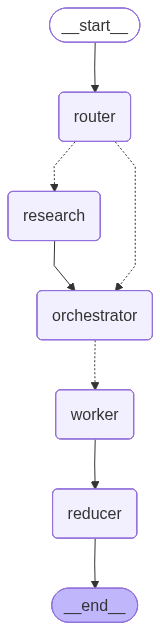

In [182]:
g = StateGraph(State)

g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "router")

g.add_conditional_edges(
    "router",
    route_next,
    {
        "research": "research",
        "orchestrator": "orchestrator"
    }
)

g.add_edge(
    "research",
    "orchestrator"
)

g.add_conditional_edges(
    "orchestrator",
    fanout,
    ["worker"]
)

g.add_edge("worker", "reducer")
g.add_edge("reducer", END)
app=g.compile()

app

In [184]:
app.invoke({"topic":"write a blog on genai latest version"})

{'query': 'OpenAI GPT-4.5 release date, new features, and performance benchmarks 2024', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.helicone.ai/blog/gpt-4.5-benchmarks', 'title': 'GPT 4.5 Released: Here Are the Benchmarks', 'content': '# GPT 4.5 Released: Here Are the Benchmarks. With Grok 3 released last week and Claude 3.7 Sonnet just days ago, OpenAI up its games with a new model **GPT-4.5** that prioritizes conversational abilities and emotional intelligence over pure reasoning power. While it hasn\'t created the excitement of previous releases, GPT-4.5 offers some interesting capabilities that developers should understand before deciding whether to integrate it into their applications. In this article, we will explore GPT-4.5\'s design, benchmarks, and real-world performance, and some tips on how to get the most out of it. GPT-4.5 is OpenAI\'s latest model, described by the company as their "largest and most knowledgeable model yet."

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01jq6wabw2fpkac3sj5kajpccs` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 14593, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}